# Lab 1. PyTorch and ANNs

This lab is a warm up to get you used to the PyTorch programming environment used
in the course, and also to help you review and renew your knowledge
of Python and relevant Python libraries.
The lab must be done individually. Please recall that the
University of Toronto plagarism rules apply.

By the end of this lab, you should be able to:

1. Be able to perform basic PyTorch tensor operations.
2. Be able to load data into PyTorch
3. Be able to configure an Artificial Neural Network (ANN) using PyTorch
4. Be able to train ANNs using PyTorch
5. Be able to evaluate different ANN configuations

You will need to use numpy and PyTorch documentations for this assignment:

* https://docs.scipy.org/doc/numpy/reference/
* https://pytorch.org/docs/stable/torch.html

You can also reference Python API documentations freely.


### What to submit

Submit a PDF file containing all your code, outputs, and write-up
from parts 1-5. You can produce a PDF of your Google Colab file by
going to `File -> Print` and then save as PDF. The Colab instructions
has more information.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission. 

**Adjust the scaling to ensure that the text is not cutoff at the margins.**

## Colab Link

Submit make sure to include a link to your colab file here

Colab Link: 

## Part 1. Python Basics [3 pt]

The purpose of this section is to get you used to the 
basics of Python, including working with functions, numbers,
lists, and strings.

Note that we **will** be checking your code for clarity and efficiency.

If you have trouble with this part of the assignment, please review http://cs231n.github.io/python-numpy-tutorial/

### Part (a) -- 1pt

Write a function `sum_of_cubes` that computes the sum of cubes up to `n`. If the input to `sum_of_cubes` invalid (e.g. negative or non-integer `n`), the function should print out `"Invalid input"` and return `-1`.

In [15]:
def sum_of_cubes(n):
    """Return the sum (1^3 + 2^3 + 3^3 + ... + n^3)

    Precondition: n > 0, type(n) == int
  
    >>> sum_of_cubes(3)
    36
    >>> sum_of_cubes(1)
    1
    """

    if n <= 0 or type(n) != int:
        return "Invalid input"
    return (n * (n + 1) // 2) ** 2
print(sum_of_cubes(3))
print(sum_of_cubes(1))


36
1


### Part (b) -- 1pt

Write a function `word_lengths` that takes a sentence (string), computes the length of each word in that sentence, and returns the length of each word in a list. You can
assume that words are always separated by a space character `" "`.

Hint: recall the `str.split` function in Python.
If you arenot sure how this function works, try
typing `help(str.split)` into a Python shell, or check out https://docs.python.org/3.6/library/stdtypes.html#str.split

In [16]:
help(str.split)

Help on method_descriptor:

split(self, /, sep=None, maxsplit=-1)
    Return a list of the words in the string, using sep as the delimiter string.
    
    sep
      The delimiter according which to split the string.
      None (the default value) means split according to any whitespace,
      and discard empty strings from the result.
    maxsplit
      Maximum number of splits to do.
      -1 (the default value) means no limit.



In [22]:
def word_lengths(sentence):
    """Return a list containing the length of each word in
    sentence.
    
    >>> word_lengths("welcome to APS360!")
    [7, 2, 7]
    >>> word_lengths("machine learning is so cool")
    [7, 8, 2, 2, 4]
    """
    words = sentence.split()   #split sentence into words
    length = []             #creat a list storing word's length

    for word in words:
        length.append(len(word))
    return length
    
print( word_lengths("welcome to APS360!"))
print(word_lengths("machine learning is so cool"))

[7, 2, 7]
[7, 8, 2, 2, 4]


### Part (c) -- 1pt

Write a function `all_same_length` that takes a sentence (string),
and checks whether every word in the string is the same length.
You should call the function `word_lengths` in the body
of this new function.


In [32]:
def all_same_length(sentence):
    """Return True if every word in sentence has the same
    length, and False otherwise.
    
    >>> all_same_length("all same length")
    False
    >>> word_lengths("hello world")
    True
    """
    len_list = word_lengths(sentence)
    for i in range(len(len_list)):
        if len_list[i]!= len_list[i-1]:
            return False
    return True
print(all_same_length("all same length"))
print(all_same_length("hello world"))


False
True


## Part 2. NumPy Exercises [5 pt]

In this part of the assignment, you'll be manipulating arrays 
usign NumPy. Normally, we use the shorter name `np` to represent
the package `numpy`.

In [37]:
import numpy as np

### Part (a) -- 1pt

The below variables `matrix` and `vector` are numpy arrays. Explain what you think `<NumpyArray>.size` and `<NumpyArray>.shape` represent.

In [55]:
matrix = np.array([[1., 2., 3., 0.5],
                   [4., 5., 0., 0.],
                   [-1., -2., 1., 1.]])
vector = np.array([2., 0., 1., -2.])

In [42]:
matrix.size
#it will tell the total elements in martix
#ie: if matrix is n*m: matrix.size = n*m """


12

In [43]:
matrix.shape

#it will tell the dimension of matrix. ie: #rows * #colomns.   n*m 

(3, 4)

In [53]:
vector.size

4

In [56]:
vector.shape
#return (size of dimension 1, size of dimension2, size of dimension 3 ....)

(4,)

### Part (b) -- 1pt

Perform matrix multiplication `output = matrix x vector` by using
for loops to iterate through the columns and rows.
Do not use any builtin NumPy functions.
Cast your output into a NumPy array, if it isn't one already.

Hint: be mindful of the dimension of output

In [85]:
output = []
n = matrix.shape[0]
m = matrix.shape[1]
result = 0

for row in range(n):
    for column in range(m):
        result += matrix[row][column] * vector[column]
    output.append(result)
    result = 0;


In [86]:
output

[np.float64(4.0), np.float64(8.0), np.float64(-3.0)]

### Part (c) -- 1pt

Perform matrix multiplication `output2 = matrix x vector` by using
the function `numpy.dot`.

We will never actually write code as in
part(c), not only because `numpy.dot` is more concise and easier to read/write, but also performance-wise `numpy.dot` is much faster (it is written in C and highly optimized).
In general, we will avoid for loops in our code.

In [75]:
output2 = np.dot(matrix, vector)

In [76]:
output2

array([ 4.,  8., -3.])

### Part (d) -- 1pt

As a way to test for consistency, show that the two outputs match.

In [84]:
print(np.array_equal(output, output2))

True


### Part (e) -- 1pt

Show that using `np.dot` is faster than using your code from part (c).

You may find the below code snippit helpful:

In [94]:
import time

# record the time before running code
start_time = time.time()

# place code to run here
for i in range(10000):
    99*99
    
# record the time after the code is run
end_time = time.time()

# compute the difference
diff = end_time - start_time
diff

0.0004432201385498047

In [95]:
import time

start_time = time.time()

output = []
n = matrix.shape[0]
m = matrix.shape[1]
result = 0

for row in range(n):
    for column in range(m):
        result += matrix[row][column] * vector[column]
    output.append(result)
    result = 0;
loop_end_time = time.time()

output2 = np.dot(matrix, vector)
function_end_time = time.time()
diff2 = function_end_time - loop_end_time
diff1 = loop_end_time - start_time
if diff2 < diff1:
    print('loop time:', diff1, '\n')
    print('np.dot time:', diff2, '\n')
    print("using `np.dot` is faster than using my code from part (c)")



loop time: 0.00018906593322753906 

np.dot time: 7.605552673339844e-05 

using `np.dot` is faster than using my code from part (c)


## Part 3. Images [6 pt]

A picture or image can be represented as a NumPy array of “pixels”, 
with dimensions H × W × C, where H is the height of the image, W is the width of the image,
and C is the number of colour channels. Typically we will use an image with channels that give the the Red, Green, and Blue “level” of each pixel, which is referred to with the short form RGB.

You will write Python code to load an image, and perform several array manipulations to the image and visualize their effects. 

In [2]:
import matplotlib.pyplot as plt

### Part (a) -- 1 pt

This is a photograph of a dog whose name is Mochi.

![alt text](https://drive.google.com/uc?export=view&id=1oaLVR2hr1_qzpKQ47i9rVUIklwbDcews)

Load the image from its url (https://drive.google.com/uc?export=view&id=1oaLVR2hr1_qzpKQ47i9rVUIklwbDcews) into the variable `img` using the `plt.imread` function.

Hint: You can enter the URL directly into the `plt.imread` function as a Python string.

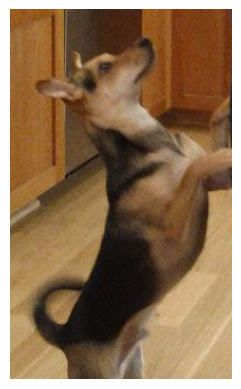

In [10]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

url = "https://drive.usercontent.google.com/download?id=1oaLVR2hr1_qzpKQ47i9rVUIklwbDcews&export=view&authuser=0"
with urllib.request.urlopen(url) as response:
    img = Image.open(response)
    img_arr = np.array(img)

plt.imshow(img_arr)
plt.axis('off')
plt.show()


### Part (b) -- 1pt

Use the function `plt.imshow` to visualize `img`. 

This function will also show the coordinate system used to identify pixels.
The origin is at the top left corner, and the first dimension indicates the Y (row) direction, 
and the second dimension indicates the X (column) dimension.

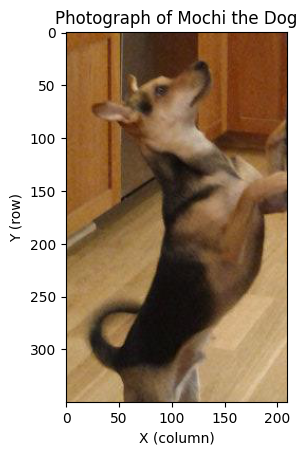

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Display the image
plt.imshow(img_arr)
plt.axis('on')  # show axes (coordinates)
plt.xlabel("X (column)")
plt.ylabel("Y (row)")
plt.title("Photograph of Mochi the Dog")
plt.show()


### Part (c) -- 2pt

Modify the image by adding a constant value of 0.25 to each pixel in the `img` and
store the result in the variable `img_add`. Note that, since the range for the pixels 
needs to be between [0, 1], you will also need to clip img_add to be in the range [0, 1] 
using `numpy.clip`. Clipping sets any value that is outside of the desired range to the 
closest endpoint. Display the image using `plt.imshow`.

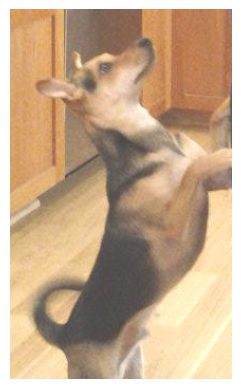

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if img_arr.max() > 1:
    img_norm = img_arr / 255.0    #since pixel range is 0-255
else:
    img_norm = img_arr.copy()


img_add = img_norm + 0.25

# Clip to stay in [0,1]
img_add = np.clip(img_add, 0, 1)

# Display the modified image
plt.imshow(img_add)
plt.axis('off')
plt.show()


### Part (d) -- 2pt

Crop the **original** image (`img` variable) to a 130 x 150 image including Mochi's face. Discard the alpha colour channel (i.e. resulting `img_cropped` should **only have RGB channels**)

Display the image.

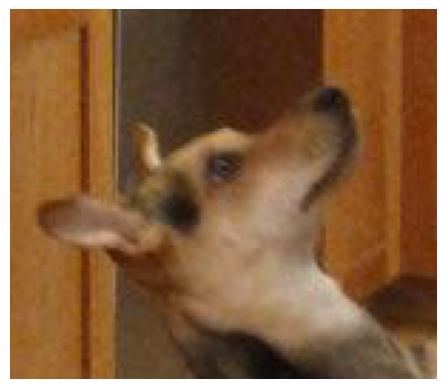

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only RGB channels (discard alpha if it exists)
img_RGB = img_arr[:, :, :3]


start_row = 0     
end_row = start_row + 130
start_col =15 
end_col = start_col + 150

# Crop the image
img_cropped = img_RGB[start_row:end_row, start_col:end_col, :]

# Display the cropped image
plt.imshow(img_cropped)
plt.axis('off')
plt.show()


## Part 4. Basics of PyTorch [6 pt]

PyTorch is a Python-based neural networks package. Along with tensorflow, PyTorch is currently one of the most popular machine learning libraries.

PyTorch, at its core, is similar to Numpy in a sense that they both 
try to make it easier to write codes for scientific computing
achieve improved performance over vanilla Python by leveraging highly optimized C back-end.
However, compare to Numpy, PyTorch offers much better GPU support and provides many high-level features for machine learning. Technically, Numpy can be used to perform almost every thing PyTorch does. However, Numpy would be a lot slower than PyTorch, especially with CUDA GPU, and it would take more effort to write machine learning related code compared to using PyTorch.

In [15]:
import torch

### Part (a) -- 1 pt

Use the function `torch.from_numpy` to convert the numpy array `img_cropped` into
a PyTorch tensor. Save the result in a variable called `img_torch`.

In [45]:
img_torch = torch.from_numpy(img_cropped)
img_torch

tensor([[[157,  96,  42],
         [156,  95,  41],
         [157,  96,  41],
         ...,
         [131,  64,  22],
         [126,  61,  19],
         [124,  59,  17]],

        [[156,  93,  40],
         [153,  90,  37],
         [156,  93,  40],
         ...,
         [131,  64,  22],
         [127,  62,  20],
         [125,  60,  18]],

        [[156,  90,  38],
         [154,  88,  36],
         [158,  92,  40],
         ...,
         [130,  63,  21],
         [126,  61,  19],
         [127,  62,  20]],

        ...,

        [[153,  97,  46],
         [157, 101,  50],
         [155,  99,  48],
         ...,
         [139, 113,  78],
         [151, 122,  88],
         [160, 131,  97]],

        [[152,  96,  45],
         [157, 101,  50],
         [155, 100,  46],
         ...,
         [141, 115,  82],
         [155, 126,  92],
         [170, 142, 105]],

        [[152,  97,  43],
         [159, 104,  50],
         [157, 102,  46],
         ...,
         [143, 117,  84],
        

### Part (b) -- 1pt

Use the method `<Tensor>.shape` to find the shape (dimension and size) of `img_torch`.

In [35]:
img_torch.shape

torch.Size([130, 150, 3])

### Part (c) -- 1pt

How many floating-point numbers are stored in the tensor `img_torch`?

In [ ]:
num_flaotingPoints = 130*150*3
#or
img_cropped.size

58500

### Part (d) -- 1 pt

What does the code `img_torch.transpose(0,2)` do? What does the expression return? 
Is the original variable `img_torch` updated? Explain.

In [ ]:
print(img_torch.transpose(0,2))     #swaps dimension of row and number of channel, ie:torch.Size([3, 150, 130])
img_torch    #not updated since .transpose is a method, which donot affect object, img_torch

tensor([[[157, 156, 156,  ..., 153, 152, 152],
         [156, 153, 154,  ..., 157, 157, 159],
         [157, 156, 158,  ..., 155, 155, 157],
         ...,
         [131, 131, 130,  ..., 139, 141, 143],
         [126, 127, 126,  ..., 151, 155, 158],
         [124, 125, 127,  ..., 160, 170, 180]],

        [[ 96,  93,  90,  ...,  97,  96,  97],
         [ 95,  90,  88,  ..., 101, 101, 104],
         [ 96,  93,  92,  ...,  99, 100, 102],
         ...,
         [ 64,  64,  63,  ..., 113, 115, 117],
         [ 61,  62,  61,  ..., 122, 126, 132],
         [ 59,  60,  62,  ..., 131, 142, 152]],

        [[ 42,  40,  38,  ...,  46,  45,  43],
         [ 41,  37,  36,  ...,  50,  50,  50],
         [ 41,  40,  40,  ...,  48,  46,  46],
         ...,
         [ 22,  22,  21,  ...,  78,  82,  84],
         [ 19,  20,  19,  ...,  88,  92,  97],
         [ 17,  18,  20,  ...,  97, 105, 113]]], dtype=torch.uint8)


tensor([[[157,  96,  42],
         [156,  95,  41],
         [157,  96,  41],
         ...,
         [131,  64,  22],
         [126,  61,  19],
         [124,  59,  17]],

        [[156,  93,  40],
         [153,  90,  37],
         [156,  93,  40],
         ...,
         [131,  64,  22],
         [127,  62,  20],
         [125,  60,  18]],

        [[156,  90,  38],
         [154,  88,  36],
         [158,  92,  40],
         ...,
         [130,  63,  21],
         [126,  61,  19],
         [127,  62,  20]],

        ...,

        [[153,  97,  46],
         [157, 101,  50],
         [155,  99,  48],
         ...,
         [139, 113,  78],
         [151, 122,  88],
         [160, 131,  97]],

        [[152,  96,  45],
         [157, 101,  50],
         [155, 100,  46],
         ...,
         [141, 115,  82],
         [155, 126,  92],
         [170, 142, 105]],

        [[152,  97,  43],
         [159, 104,  50],
         [157, 102,  46],
         ...,
         [143, 117,  84],
        

### Part (e) -- 1 pt

What does the code `img_torch.unsqueeze(0)` do? What does the expression return? 
Is the original variable `img_torch` updated? Explain.

In [ ]:
print(img_torch.unsqueeze(0))
img_torch.unsqueeze(2)

#img_torch.unsqueeze(0) adds a dimension to img_torch at index 0, method unsqueeze(dim) and squeeze(dim) can make computer see different sides of onject
#eg: by img_torch.unsqueeze(0), computer can see 3-dimensional instad of 2 dimension.
img_torch
#img_torch will not be updated since .unsqueeze is a method which not change object, if we want to updated img_torch, we can assign img_torch.unsqueeze(2) to img_torch
#ie: img_torch = img_torch.unsqueeze(2)

tensor([[[[157,  96,  42]],

         [[156,  95,  41]],

         [[157,  96,  41]],

         ...,

         [[131,  64,  22]],

         [[126,  61,  19]],

         [[124,  59,  17]]],


        [[[156,  93,  40]],

         [[153,  90,  37]],

         [[156,  93,  40]],

         ...,

         [[131,  64,  22]],

         [[127,  62,  20]],

         [[125,  60,  18]]],


        [[[156,  90,  38]],

         [[154,  88,  36]],

         [[158,  92,  40]],

         ...,

         [[130,  63,  21]],

         [[126,  61,  19]],

         [[127,  62,  20]]],


        ...,


        [[[153,  97,  46]],

         [[157, 101,  50]],

         [[155,  99,  48]],

         ...,

         [[139, 113,  78]],

         [[151, 122,  88]],

         [[160, 131,  97]]],


        [[[152,  96,  45]],

         [[157, 101,  50]],

         [[155, 100,  46]],

         ...,

         [[141, 115,  82]],

         [[155, 126,  92]],

         [[170, 142, 105]]],


        [[[152,  97,  43]],

 

tensor([[[157,  96,  42],
         [156,  95,  41],
         [157,  96,  41],
         ...,
         [131,  64,  22],
         [126,  61,  19],
         [124,  59,  17]],

        [[156,  93,  40],
         [153,  90,  37],
         [156,  93,  40],
         ...,
         [131,  64,  22],
         [127,  62,  20],
         [125,  60,  18]],

        [[156,  90,  38],
         [154,  88,  36],
         [158,  92,  40],
         ...,
         [130,  63,  21],
         [126,  61,  19],
         [127,  62,  20]],

        ...,

        [[153,  97,  46],
         [157, 101,  50],
         [155,  99,  48],
         ...,
         [139, 113,  78],
         [151, 122,  88],
         [160, 131,  97]],

        [[152,  96,  45],
         [157, 101,  50],
         [155, 100,  46],
         ...,
         [141, 115,  82],
         [155, 126,  92],
         [170, 142, 105]],

        [[152,  97,  43],
         [159, 104,  50],
         [157, 102,  46],
         ...,
         [143, 117,  84],
        

### Part (f) -- 1 pt

Find the maximum value of `img_torch` along each colour channel? Your output should be a one-dimensional
PyTorch tensor with exactly three values.

Hint: lookup the function `torch.max`.

In [94]:
#to find maxium value along each color channel, we need merge(reshape torch) Height and Length first, ie: [H, L, C] -> [HxL, C]
#3 tells each row has 3 elemnt: R# G# B#, -1 claculates automatically how many rows are needed, dim = 0 checks row by row in same coloum
channel_max = torch.max(img_torch.reshape(-1, 3), dim=0).values
channel_max

tensor([228, 201, 172], dtype=torch.uint8)

## Part 5. Training an ANN [10 pt]

The sample code provided below is a 2-layer ANN trained on the MNIST dataset to identify digits less than 3 or greater than and equal to 3. Modify the code by changing any of the following and observe how the accuracy and error are affected:

- number of training iterations
- number of hidden units
- numbers of layers
- types of activation functions
- learning rate

Please select at least three different options from the list above. For each option, please select two to three different parameters and provide a table. 


In [143]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt # for plotting
import torch.optim as optim

torch.manual_seed(1) # set the random seed

# define a 2-layer artificial neural network
class Pigeon(nn.Module):
    def __init__(self):
        super(Pigeon, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 300)
        self.layer2 = nn.Linear(300, 1)
        #self.layer3 = nn.Linear(10, 1)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.layer1(flattened)
        activation1 = F.relu(activation1)
        activation2 = self.layer2(activation1)
        #activation3 = self.layer3(activation2)
        return activation2          #activation3

pigeon = Pigeon()

# load the data
mnist_data = datasets.MNIST('data', train=True, download=True)
mnist_data = list(mnist_data)
mnist_train = mnist_data[:50000]
mnist_val   = mnist_data[1000:2000]
img_to_tensor = transforms.ToTensor()
      
    
# simplified training code to train `pigeon` on the "small digit recognition" task
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(pigeon.parameters(), lr=0.005, momentum=0.9)

for (image, label) in mnist_train:
    # actual ground truth: is the digit less than 3?
    actual = torch.tensor(label < 3).reshape([1,1]).type(torch.FloatTensor)
    # pigeon prediction
    out = pigeon(img_to_tensor(image)) # step 1-2
    # update the parameters based on the loss
    loss = criterion(out, actual)      # step 3
    loss.backward()                    # step 4 (compute the updates for each parameter)
    optimizer.step()                   # step 4 (make the updates for each parameter)
    optimizer.zero_grad()              # a clean up step for PyTorch

# computing the error and accuracy on the training set
error = 0
for (image, label) in mnist_train:
    prob = torch.sigmoid(pigeon(img_to_tensor(image)))
    if (prob < 0.5 and label < 3) or (prob >= 0.5 and label >= 3):
        error += 1
print("Training Error Rate:", error/len(mnist_train))
print("Training Accuracy:", 1 - error/len(mnist_train))


# computing the error and accuracy on a test set
error = 0
for (image, label) in mnist_val:
    prob = torch.sigmoid(pigeon(img_to_tensor(image)))
    if (prob < 0.5 and label < 3) or (prob >= 0.5 and label >= 3):
        error += 1
print("Test Error Rate:", error/len(mnist_val))
print("Test Accuracy:", 1 - error/len(mnist_val))

Training Error Rate: 0.01346
Training Accuracy: 0.98654
Test Error Rate: 0.022
Test Accuracy: 0.978


### Part (a) -- 3 pt
Comment on which of the above changes resulted in the best accuracy on training data? What accuracy were you able to achieve?

In [145]:
"""
ANS: increasing trainig iteration from 1000 to 50000, I am able to achieve 0.964 for test accuracy

"""




"""
initial:        Training Error Rate: 0.036
                Training Accuracy: 0.964
                Test Error Rate: 0.079
                Test Accuracy: 0.921

training iteration:  increase to 50000: training accuracy decrease by 0.02254
                        Training Error Rate: 0.01346
                        Training Accuracy: 0.98654
                        Test Error Rate: 0.022
                        Test Accuracy: 0.978
                    
hidden units: increase to 100, 250, 320, 300 and 300 brings highes accuracy for both training and test:   training accuracy increase by 0.013
                        Training Error Rate: 0.023
                        Training Accuracy: 0.977
                        Test Error Rate: 0.071
                        Test Accuracy: 0.929
                
number of layers: add 1 more layer:  no change
                        Training Error Rate: 0.036
                        Training Accuracy: 0.964
                        Test Error Rate: 0.082
                        Test Accuracy: 0.918

types of activation function:   change F.relu to F.tanh:  decrease by 0.004
                        Training Error Rate: 0.04
                        Training Accuracy: 0.96
                        Test Error Rate: 0.094
                        Test Accuracy: 0.906

learning rate: change lr = 0.005 to 0.1: training rate decreases significantly, but when lr = 0.004 training accuracy increases by 0.003
                        Training Error Rate: 0.312
                        Training Accuracy: 0.688
                        Test Error Rate: 0.297
                        Test Accuracy: 0.7030000000000001
when lr = 0.004: training accurancy increases by 0.003
                        Training Error Rate: 0.033
                        Training Accuracy: 0.967
                        Test Error Rate: 0.084
                        Test Accuracy: 0.916
"""


'\ninitial:        Training Error Rate: 0.036\n                Training Accuracy: 0.964\n                Test Error Rate: 0.079\n                Test Accuracy: 0.921\n\ntraining iteration:  increase to 50000: training accuracy decrease by 0.02254\n                        Training Error Rate: 0.01346\n                        Training Accuracy: 0.98654\n                        Test Error Rate: 0.022\n                        Test Accuracy: 0.978\n                    \nhidden units: increase to 100, 250, 320, 300 and 300 brings highes accuracy for both training and test:   training accuracy increase by 0.013\n                        Training Error Rate: 0.023\n                        Training Accuracy: 0.977\n                        Test Error Rate: 0.071\n                        Test Accuracy: 0.929\n                \nnumber of layers: add 1 more layer:  no change\n                        Training Error Rate: 0.036\n                        Training Accuracy: 0.964\n                       

### Part (b) -- 3 pt


Comment on which of the above changes resulted in the best accuracy on testing data? What accuracy were you able to achieve?

In [146]:
"""
ANS:  increasing training iteration from 1000 to 50000: test accuracy i can achieve is 0.978
"""


"""
training iteration: increase to 50000: test accuracy increase: 0.921 -> 0.978  increase by 0.057
hidden units: increase to 100, 250, 320, 300 and 300 brings highes accuracy for both training and test:   test accuracy increase by 0.008.  increase
number of layers: add 1 more layer:  0.921 -> 0.918         decrease 
types of activation function:   change F.relu to F.tanh: 0.921 -> 0.906       decrease
learning rate: change lr = 0.005 to 0.1, 0.04, 0.06: training rate decreases significantly
"""

'\ntraining iteration: increase to 50000: test accuracy increase: 0.921 -> 0.978  increase by 0.057\nhidden units: increase to 100, 250, 320, 300 and 300 brings highes accuracy for both training and test:   test accuracy increase by 0.008.  increase\nnumber of layers: add 1 more layer:  0.921 -> 0.918         decrease \ntypes of activation function:   change F.relu to F.tanh: 0.921 -> 0.906       decrease\nlearning rate: change lr = 0.005 to 0.1, 0.04, 0.06: training rate decreases significantly\n'

### Part (c) -- 4 pt
Which model hyperparameters should you use, the ones from (a) or (b)?

In [ ]:
"""best hyperparamenter i shoudl use is: in icnreasing iteration when traning interation is 50000"""